C:\Users\tolan\AppData\Local\Temp\ipykernel_11628\1008517201.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{abs(int(t))}" if float(t).is_integer() else f"{abs(t):.1f}" for t in ticks])


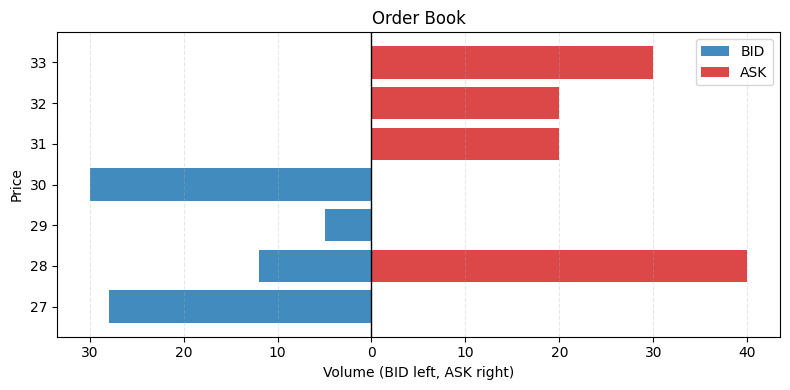

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_order_book(csv_path: str, top_n: int | None = None, sort_desc: bool = True):
    """Plot a simple order book from a CSV with columns: BID, PRICE, ASK.

    BID and ASK are plotted as mirrored horizontal bars at each price level.
    """
    df = pd.read_csv(csv_path)

    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # Keep numeric rows only and aggregate duplicate price levels.
    book = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
    )

    book = book.sort_values("PRICE", ascending=not sort_desc)
    if top_n is not None:
        book = book.head(top_n)

    fig, ax = plt.subplots(figsize=(8, max(4, len(book) * 0.45)))

    # Mirror bids to the left, asks to the right.
    ax.barh(book["PRICE"], -book["BID"], color="#1f77b4", alpha=0.85, label="BID")
    ax.barh(book["PRICE"],  book["ASK"], color="#d62728", alpha=0.85, label="ASK")

    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Volume (BID left, ASK right)")
    ax.set_ylabel("Price")
    ax.set_title("Order Book")
    ax.legend()
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    # Use absolute labels on the x-axis for readability.
    ticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(int(t))}" if float(t).is_integer() else f"{abs(t):.1f}" for t in ticks])

    plt.tight_layout()
    plt.show()


# Example usage:
plot_order_book("DRYLAND_FLAX.csv")

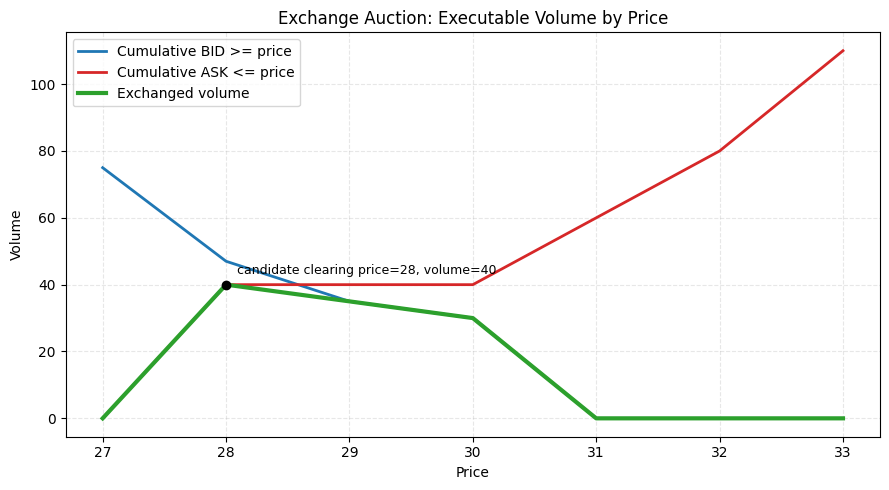

,PRICE,cum_bid_ge_price,cum_ask_le_price,exchanged_volume
0,27,75,0,0
1,28,47,40,40
2,29,35,40,35
3,30,30,40,30
4,31,0,60,0
5,32,0,80,0
6,33,0,110,0


In [2]:
def plot_auction_exchanged_volume(csv_path: str):
    """Graph the executable auction volume at each candidate clearing price.

    For each price p:
    - demand(p) = total BID volume at prices >= p
    - supply(p) = total ASK volume at prices <= p
    - exchanged(p) = min(demand(p), supply(p))
    """
    df = pd.read_csv(csv_path)

    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    book = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
        .sort_values("PRICE")
    )

    # Cumulative supply from low to high prices.
    book["cum_ask_le_price"] = book["ASK"].cumsum()

    # Cumulative demand from high to low prices.
    book["cum_bid_ge_price"] = book["BID"][::-1].cumsum()[::-1]

    # Auction matched volume at each candidate clearing price.
    book["exchanged_volume"] = book[["cum_ask_le_price", "cum_bid_ge_price"]].min(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(book["PRICE"], book["cum_bid_ge_price"], label="Cumulative BID >= price", color="#1f77b4", linewidth=2)
    ax.plot(book["PRICE"], book["cum_ask_le_price"], label="Cumulative ASK <= price", color="#d62728", linewidth=2)
    ax.plot(book["PRICE"], book["exchanged_volume"], label="Exchanged volume", color="#2ca02c", linewidth=3)

    # Mark one clearing-price candidate with maximal exchanged volume.
    max_exchanged = book["exchanged_volume"].max()
    best = book[book["exchanged_volume"] == max_exchanged].iloc[0]
    ax.scatter(best["PRICE"], best["exchanged_volume"], color="black", zorder=5)
    ax.annotate(
        f"candidate clearing price={best['PRICE']}, volume={best['exchanged_volume']}",
        (best["PRICE"], best["exchanged_volume"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
    )

    ax.set_title("Exchange Auction: Executable Volume by Price")
    ax.set_xlabel("Price")
    ax.set_ylabel("Volume")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return book[["PRICE", "cum_bid_ge_price", "cum_ask_le_price", "exchanged_volume"]]


# Example usage (switch file name if needed):
plot_auction_exchanged_volume("DRYLAND_FLAX.csv")

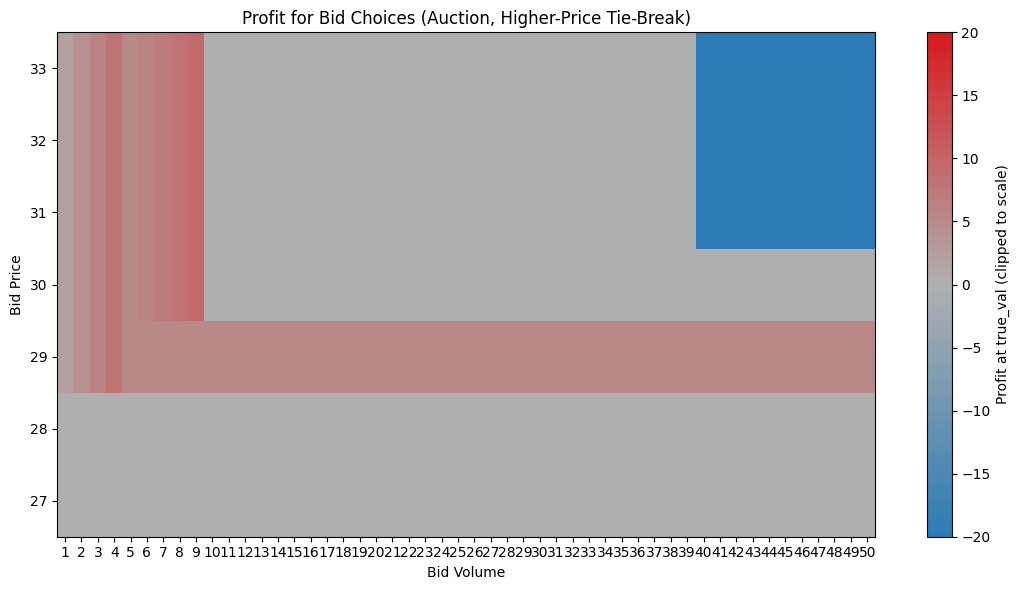

,bid_price,bid_volume,clearing_price,executed_volume,profit_at_true_val
0,27.0,1,28.0,0.0,0.0
1,27.0,2,28.0,0.0,0.0
2,27.0,3,28.0,0.0,0.0
3,27.0,4,28.0,0.0,0.0
4,27.0,5,28.0,0.0,0.0


In [13]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


def simulate_last_in_queue_bid_sweep(
    csv_path: str,
    max_volume: int = 50,
    true_val: float | None = None,
    plot: bool = True,
    profit_vmin: float = -20.0,
    profit_vmax: float = 20.0,
):
    """Try placing our BID at each price and volume (1..max_volume).

    Auction rules used here:
    - Clearing price maximizes matched volume, tie-broken by higher price.
    - Execution has price priority.
    - At the same price level, existing queue executes first (our order is last).

    If true_val is provided, profit is computed as:
    profit = executed_volume * (true_val - clearing_price)
    """
    df = pd.read_csv(csv_path)
    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    if profit_vmin >= 0 or profit_vmax <= 0 or profit_vmin >= profit_vmax:
        raise ValueError("Use profit_vmin < 0 < profit_vmax for centered profit scaling.")

    base = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
    )

    base_prices = np.sort(base["PRICE"].unique())
    bid_by_price = dict(zip(base["PRICE"], base["BID"]))
    ask_by_price = dict(zip(base["PRICE"], base["ASK"]))

    def _matched_curves(prices, bid_map, ask_map):
        b = np.array([bid_map.get(p, 0.0) for p in prices], dtype=float)
        a = np.array([ask_map.get(p, 0.0) for p in prices], dtype=float)
        demand_ge = b[::-1].cumsum()[::-1]   # buy volume willing to pay >= p
        supply_le = a.cumsum()               # sell volume willing to accept <= p
        matched = np.minimum(demand_ge, supply_le)
        return demand_ge, supply_le, matched

    def _choose_clearing_price(prices, matched):
        max_m = matched.max()
        idx = np.where(matched == max_m)[0]
        return prices[idx[-1]], max_m  # higher price tie-break

    records = []

    for test_price in base_prices:
        for vol in range(1, max_volume + 1):
            all_prices = np.unique(np.append(base_prices, test_price))
            all_prices.sort()

            bid_map = dict(bid_by_price)
            bid_map[test_price] = bid_map.get(test_price, 0.0) + vol
            ask_map = dict(ask_by_price)

            _, supply_le, matched = _matched_curves(all_prices, bid_map, ask_map)
            clearing_price, _ = _choose_clearing_price(all_prices, matched)

            cp_idx = np.where(all_prices == clearing_price)[0][0]
            total_supply = supply_le[cp_idx]
            buy_above_cp = sum(bid_map.get(p, 0.0) for p in all_prices if p > clearing_price)
            alloc_for_cp_bids = max(0.0, total_supply - buy_above_cp)

            if test_price > clearing_price:
                # Better price than clearing price: fully executed.
                our_exec = float(vol)
            elif test_price < clearing_price:
                our_exec = 0.0
            else:
                # At clearing price and last in queue: existing bids at cp fill first.
                existing_at_cp = bid_by_price.get(clearing_price, 0.0)
                remaining_after_existing = max(0.0, alloc_for_cp_bids - existing_at_cp)
                our_exec = float(min(vol, remaining_after_existing))

            profit_at_true_val = (
                float(our_exec * (true_val - clearing_price)) if true_val is not None else np.nan
            )

            records.append(
                {
                    "bid_price": float(test_price),
                    "bid_volume": int(vol),
                    "clearing_price": float(clearing_price),
                    "executed_volume": our_exec,
                    "profit_at_true_val": profit_at_true_val,
                }
            )

    result = pd.DataFrame(records)

    if plot:
        if true_val is None:
            raise ValueError("Set true_val to plot profit.")

        pivot = result.pivot(index="bid_price", columns="bid_volume", values="profit_at_true_val")

        # Center color mapping at zero with fixed profit caps.
        z = pivot.values.astype(float)
        z = np.clip(z, profit_vmin, profit_vmax)
        norm = TwoSlopeNorm(vmin=profit_vmin, vcenter=0.0, vmax=profit_vmax)
        cmap = LinearSegmentedColormap.from_list(
            "profit_blue_grey_red",
            ["#2C7BB6", "#B0B0B0", "#D7191C"],
            N=256,
        )

        fig, ax = plt.subplots(figsize=(11, 6))
        im = ax.imshow(z, aspect="auto", origin="lower", cmap=cmap, norm=norm)
        ax.set_title("Profit for Bid Choices (Auction, Higher-Price Tie-Break)")
        ax.set_xlabel("Bid Volume")
        ax.set_ylabel("Bid Price")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{p:g}" for p in pivot.index])
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Profit at true_val (clipped to scale)")
        plt.tight_layout()
        plt.show()

    return result


sweep = simulate_last_in_queue_bid_sweep(
    "DRYLAND_FLAX.csv",
    max_volume=50,
    true_val=30,
    plot=True,
    profit_vmin=-20,
    profit_vmax=20,
)
sweep.head()

In [11]:
# Sort by profit descending and print top rows
sweep_top = sweep.sort_values("profit_at_true_val", ascending=False)
print(sweep_top.head(20).to_string(index=False))

# Keep a display-friendly object as well
sweep_top.head(20)

 bid_price  bid_volume  clearing_price  executed_volume  profit_at_true_val
      32.0           9            29.0              9.0                 9.0
      31.0           9            29.0              9.0                 9.0
      30.0           9            29.0              9.0                 9.0
      33.0           9            29.0              9.0                 9.0
      31.0           4            28.0              4.0                 8.0
      31.0           8            29.0              8.0                 8.0
      30.0           8            29.0              8.0                 8.0
      32.0           4            28.0              4.0                 8.0
      32.0           8            29.0              8.0                 8.0
      30.0           4            28.0              4.0                 8.0
      29.0           4            28.0              4.0                 8.0
      33.0           4            28.0              4.0                 8.0
      33.0  

,bid_price,bid_volume,clearing_price,executed_volume,profit_at_true_val
258,32.0,9,29.0,9.0,9.0
208,31.0,9,29.0,9.0,9.0
158,30.0,9,29.0,9.0,9.0
308,33.0,9,29.0,9.0,9.0
203,31.0,4,28.0,4.0,8.0
207,31.0,8,29.0,8.0,8.0
157,30.0,8,29.0,8.0,8.0
253,32.0,4,28.0,4.0,8.0
257,32.0,8,29.0,8.0,8.0
153,30.0,4,28.0,4.0,8.0


In [2]:
import pandas as pd
import numpy as np


def sweep_bid_quantity_range_auction(
    csv_path: str,
    quantity_range_min: float,
    quantity_range_max: float,
    bid_price: float,
    true_val: float = 20.0,
    fee_per_volume: float = 0.0,
    step: float = 0.001,
):
    """Sweep candidate bid quantities and evaluate auction outcome for each.

    Uses auction clearing-price logic:
    - Clearing price maximizes matched volume, tie-broken by higher price.

    Execution rule for our tested order:
    - Price priority applies.
    - No time priority at the same price (pro-rata allocation at clearing price).

    Profit:
    - executed_volume * (true_val - clearing_price - fee_per_volume)
    """
    if step <= 0:
        raise ValueError("step must be > 0")
    if quantity_range_max < quantity_range_min:
        raise ValueError("quantity_range_max must be >= quantity_range_min")
    if bid_price <= 0:
        raise ValueError("bid_price must be > 0")

    df = pd.read_csv(csv_path)
    required = {"BID", "PRICE", "ASK"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    base = (
        df[["BID", "PRICE", "ASK"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna(subset=["PRICE"])
        .fillna(0)
        .groupby("PRICE", as_index=False)[["BID", "ASK"]]
        .sum()
    )

    base_prices = np.sort(base["PRICE"].unique())
    bid_by_price = dict(zip(base["PRICE"], base["BID"]))
    ask_by_price = dict(zip(base["PRICE"], base["ASK"]))

    def _matched_curves(prices, bid_map, ask_map):
        bids = np.array([bid_map.get(p, 0.0) for p in prices], dtype=float)
        asks = np.array([ask_map.get(p, 0.0) for p in prices], dtype=float)
        demand_ge = bids[::-1].cumsum()[::-1]
        supply_le = asks.cumsum()
        matched = np.minimum(demand_ge, supply_le)
        return demand_ge, supply_le, matched

    def _choose_clearing_price(prices, matched):
        max_m = matched.max()
        idx = np.where(matched == max_m)[0]
        return prices[idx[-1]], max_m

    n_steps = int(round((quantity_range_max - quantity_range_min) / step))
    records = []

    for i in range(n_steps + 1):
        test_qty = round(quantity_range_min + i * step, 3)

        all_prices = np.unique(np.append(base_prices, bid_price))
        all_prices.sort()

        bid_map = dict(bid_by_price)
        ask_map = dict(ask_by_price)
        bid_map[bid_price] = bid_map.get(bid_price, 0.0) + test_qty

        _, supply_le, matched = _matched_curves(all_prices, bid_map, ask_map)
        clearing_price, matched_volume = _choose_clearing_price(all_prices, matched)

        cp_idx = np.where(all_prices == clearing_price)[0][0]
        total_supply = supply_le[cp_idx]
        buy_above_cp = sum(bid_map.get(p, 0.0) for p in all_prices if p > clearing_price)
        alloc_for_cp_bids = max(0.0, total_supply - buy_above_cp)

        if bid_price > clearing_price:
            executed = float(test_qty)
        elif bid_price < clearing_price:
            executed = 0.0
        else:
            # Same price as clearing: pro-rata among all bids at clearing price.
            existing_at_cp = bid_by_price.get(clearing_price, 0.0)
            total_at_cp = existing_at_cp + test_qty
            if total_at_cp <= 0:
                executed = 0.0
            else:
                executed = float(min(test_qty, alloc_for_cp_bids * (test_qty / total_at_cp)))

        score = float(executed * (true_val - clearing_price - fee_per_volume))

        records.append(
            {
                "bid_price": float(bid_price),
                "bid_quantity": float(test_qty),
                "clearing_price": float(clearing_price),
                "matched_volume": float(matched_volume),
                "executed_volume": executed,
                "score": score,
            }
        )

    return pd.DataFrame(records)


results = sweep_bid_quantity_range_auction(
    "DRYLAND_FLAX.csv",
    quantity_range_min=9,
    quantity_range_max=11,
    bid_price=30,
    true_val=30,
    fee_per_volume=0.0,
    step=0.001,
)

best_result = results.loc[results["score"].idxmax()]
print(
    f"Best qty={best_result['bid_quantity']:.3f}, "
    f"bid={best_result['bid_price']:.3f}, "
    f"clearing={best_result['clearing_price']:.3f}, "
    f"exec={best_result['executed_volume']:.3f}, "
    f"score={best_result['score']:.3f}"
)
print(f"Total iterations: {len(results)}")
results.head()

Best qty=9.999, bid=30.000, clearing=29.000, exec=9.999, score=9.999
Total iterations: 2001


,bid_price,bid_quantity,clearing_price,matched_volume,executed_volume,score
0,30.0,9.000,29.0,40.0,9.000,9.000
1,30.0,9.001,29.0,40.0,9.001,9.001
2,30.0,9.002,29.0,40.0,9.002,9.002
3,30.0,9.003,29.0,40.0,9.003,9.003
4,30.0,9.004,29.0,40.0,9.004,9.004
